# Python vizualizācija — Matplotlib, Seaborn un Plotly

Šī piezīmju grāmata (notebook) ir paredzēta lekcijai **“Python vizualizācija”** un balstās uz kursa aprakstu:
- Matplotlib pamati
- Seaborn statistiskās vizualizācijas
- Interaktīvās vizualizācijas ar Plotly
- Prezentācijām piemēroti grafiki

Konteksts: studenti iepriekšējā nodarbībā jau ir strādājuši ar **Pandas**, **Jupyter Notebooks** un **Google Colab**.

## Mācību mērķi
Pēc šīs nodarbības studentam jāspēj:
1. izveidot skaidru statisku grafiku ar **Matplotlib**;
2. izmantot **Seaborn** statistiskai datu izpētei;
3. izveidot interaktīvu grafiku ar **Plotly**;
4. izvēlēties piemērotu grafika tipu konkrētam jautājumam;
5. ievērot pamata labās prakses principus profesionālās vizualizācijās.

## Datu kopa
Tiek izmantota sintētiska, bet reālistiska datu kopa par reģioniem, izdevumu kategorijām un iedzīvotāju apmierinātību Latvijā.

**Fails:** `python_vizualizacija_dati.csv`


## 1. Sagatavošanās

Šajā sadaļā importēsim vajadzīgās bibliotēkas un ielādēsim datus.


In [ ]:
# Ja strādājat Google Colab un nepieciešams Plotly/Seaborn jaunāks variants,
# var atkomentēt nākamo rindu:
# !pip install seaborn plotly -q

# šīs bibliotekas nav iebūvētas Python standarta bibliotēkā, 
# tāpēc tās ir jāinstalē, ja vēl nav pieejamas.
print("Ja ir kļūda tad bibliotēkas nav pieejamas, lūdzu instalējiet tās pirms turpināt.")
print("Instalējam no komandrindas, ja nepieciešams:")
# we also need openpyxl for reading Excel files, but in this case we are using CSV, so it's not required.
print("pip install pandas numpy matplotlib seaborn plotly openpyxl")
# Google Colab tām jau būtu jābūt pieejamām, bet vietējā vidē var būt nepieciešams tās instalēt.

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

# ja nestrādā kāda no bibliotekām, var atkomentēt nākamo rindu un instalēt trūkstošo bibliotēku
print("Bibliotēkas ir pieejamas un gatavas lietošanai!")


# Labāka attēlu kvalitāte Jupyter/Colab vidē
plt.rcParams["figure.dpi"] = 130
sns.set_theme(style="whitegrid")

# Mēģinām nolasīt ārējo CSV failu.
# Ja fails nav pieejams, izveidojam to no iekšā definēta saraksta.
try:
    df = pd.read_csv("python_vizualizacija_dati.csv")
except FileNotFoundError: # plāns B, ja fails nav pieejams
    df = pd.read_csv("https://raw.githubusercontent.com/ValRCS/RTU_Digitalas_Prasmes_Excel_VBA_Python/refs/heads/main/notebooks/python_vizualizacija_dati.csv")

df.head()


Bibliotēkas ir pieejamas un gatavas lietošanai!


,gads,regions,kategorija,izdevumi_milj_eur,projektu_skaits,iedzivotaju_apmierinatiba,pakalpojuma_lietotaji
0,2020,Rīga,Izglītība,69.82,10,78.5,66597
1,2020,Rīga,Veselība,70.67,10,72.0,62339
2,2020,Rīga,Transports,59.94,9,70.0,57058
3,2020,Rīga,Kultūra,30.23,7,82.4,23771
4,2020,Rīga,Sociālā aizsardzība,47.54,6,72.0,42587


## 2. Datu iepazīšana

Pirms veidot grafikus, vienmēr jāsaprot:
- kādas ir kolonnas,
- kādi ir datu tipi,
- vai ir tukšas vērtības,
- kāds jautājums vispār tiek uzdots datiem.


In [4]:
# Izpētiet datu struktūru
df.info()

# Papildu uzdevums:
# apskatiet pirmās 5 rindas un aprakstiet, ko nozīmē katra kolonna
# df.head()

<class 'pandas.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 7 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   gads                       150 non-null    int64  
 1   regions                    150 non-null    str    
 2   kategorija                 150 non-null    str    
 3   izdevumi_milj_eur          150 non-null    float64
 4   projektu_skaits            150 non-null    int64  
 5   iedzivotaju_apmierinatiba  150 non-null    float64
 6   pakalpojuma_lietotaji      150 non-null    int64  
dtypes: float64(2), int64(3), str(2)
memory usage: 8.3 KB


In [5]:
df.describe() # parāda tikai skaitliskās kolonnas, bet ne kategoriskās

,gads,izdevumi_milj_eur,projektu_skaits,iedzivotaju_apmierinatiba,pakalpojuma_lietotaji
count,150.000000,150.000000,150.000000,150.000000,150.000000
mean,2022.500000,48.785200,8.066667,72.535333,43824.573333
std,1.713547,17.099131,3.142407,6.730718,15914.491051
min,2020.000000,16.020000,2.000000,56.200000,11022.000000
25%,2021.000000,35.672500,6.000000,67.325000,32325.250000
50%,2022.500000,48.950000,8.000000,72.100000,44037.000000
75%,2024.000000,60.442500,10.000000,77.275000,52782.500000
max,2025.000000,94.820000,16.000000,87.700000,88660.000000


In [6]:
# kā parādīt visas kolonnas, ieskaitot kategoriskās?
df.describe(include="all")

,gads,regions,kategorija,izdevumi_milj_eur,projektu_skaits,iedzivotaju_apmierinatiba,pakalpojuma_lietotaji
count,150.000000,150,150,150.000000,150.000000,150.000000,150.000000
unique,NaN,5,5,NaN,NaN,NaN,NaN
top,NaN,Rīga,Izglītība,NaN,NaN,NaN,NaN
freq,NaN,30,30,NaN,NaN,NaN,NaN
mean,2022.500000,NaN,NaN,48.785200,8.066667,72.535333,43824.573333
std,1.713547,NaN,NaN,17.099131,3.142407,6.730718,15914.491051
min,2020.000000,NaN,NaN,16.020000,2.000000,56.200000,11022.000000
25%,2021.000000,NaN,NaN,35.672500,6.000000,67.325000,32325.250000
50%,2022.500000,NaN,NaN,48.950000,8.000000,72.100000,44037.000000
75%,2024.000000,NaN,NaN,60.442500,10.000000,77.275000,52782.500000


In [8]:
# kā šādu pārskatu saglabāt kā CSV failu?
# papildus Transponējam, lai kolonnas būtu rindās un saglabājam ar indeksu, lai saglabātu informāciju par kolonnu nosaukumiem
df.describe(include="all").T.to_csv("datu_apraksts.csv", index=True) # indekss šeit vajadzīgs, lai saglabātu informāciju par kolonnu nosaukumiem
# atceramies ka Google Colab vidē šis fails būs pieejams tikai sesijas laikā, bet vietējā vidē tas būs pieejams pastāvīgi.
# ja esat Google Colab tad vajadzēs vēl lejuplādēt šo failu, lai to varētu apskatīt ārpus Colab vidē. To var izdarīt ar šādu kodu:
# lokāli google.colab bibliotēka nav pieejama, tāpēc šo rindu var atkomentēt tikai Google Colab vidē.
# from google.colab import files
# files.download("datu_apraksts.csv")

## 3. Labā prakse vizualizācijās

Pirms ķeramies pie bibliotēkām, paturiet prātā dažus principus.

### Pamatprincipi
1. **Grafikam jāatbild uz jautājumu**, nevis vienkārši jāizskatās iespaidīgi.
2. **Izvēlieties pareizo grafika tipu**:
   - laika rindām — line chart jeb līniju diagramma,
   - kategoriju salīdzināšanai — bar chart jeb stabiņu diagramma,
   - sadalījumiem — histogramma vai boxplot (latviski — kastīšu diagramma),
   - sakarībām starp skaitliskiem mainīgajiem — scatter plot jeb punktu diagramma.
3. **Nepārslogojiet grafiku** ar pārāk daudz krāsām, etiķetēm un dekorācijām.
4. **Nosaukums, asu nosaukumi un leģenda** nav izvēles greznība — tie ir obligāti.
5. **Krāsu lietojumam jābūt semantiski pamatotam**.
6. **Prezentācijām** vajag lielākus fontus, mazāk sīku detaļu un vienu galveno domu vienā grafikā.


## 4. Matplotlib pamati

Šajā sadaļā veidosiet savus pirmos statiskos grafikus.


### Uzdevums 4.1. Līniju grafiks pa gadiem

Izveidojiet tabulu, kur katram gadam ir aprēķināta **kopējā izdevumu summa**, un uzzīmējiet to kā līniju grafiku.

**Prasības:**
- izmantojiet `groupby()`,
- uzlieciet virsrakstu,
- nosauciet abas asis,
- pievienojiet režģi.


In [9]:
# parādam galvu atkal
df.head()

,gads,regions,kategorija,izdevumi_milj_eur,projektu_skaits,iedzivotaju_apmierinatiba,pakalpojuma_lietotaji
0,2020,Rīga,Izglītība,69.82,10,78.5,66597
1,2020,Rīga,Veselība,70.67,10,72.0,62339
2,2020,Rīga,Transports,59.94,9,70.0,57058
3,2020,Rīga,Kultūra,30.23,7,82.4,23771
4,2020,Rīga,Sociālā aizsardzība,47.54,6,72.0,42587


In [ ]:
# pirms Group By es varēju veikt value counts gads kolonai, lai redzētu cik ierakstu ir katram gadam
df["gads"].value_counts()
# redzam cik katrā gadā ir ierakstu, un varam secināt, ka mums ir vienmērīgi sadalīti dati pa gadiem, kas ir labi, jo tas ļauj mums veikt salīdzinājumus starp gadiem bez bažām par datu trūkumu kādā gadā.

gads
2020    25
2021    25
2022    25
2023    25
2024    25
2025    25
Name: count, dtype: int64

In [ ]:
# TODO:
# 1. Izveidojiet DataFrame izdevumi_pa_gadiem
izdevumi_pa_gadiem = df.groupby("gads")["izdevumi_milj_eur"].sum().reset_index()
# parādam šo jauno DataFrame sākumu
izdevumi_pa_gadiem.head(15) # mums jau tikai 6 gadi



,gads,izdevumi_milj_eur
0,2020,1067.05
1,2021,1140.99
2,2022,1201.90
3,2023,1254.20
4,2024,1296.78
5,2025,1356.86


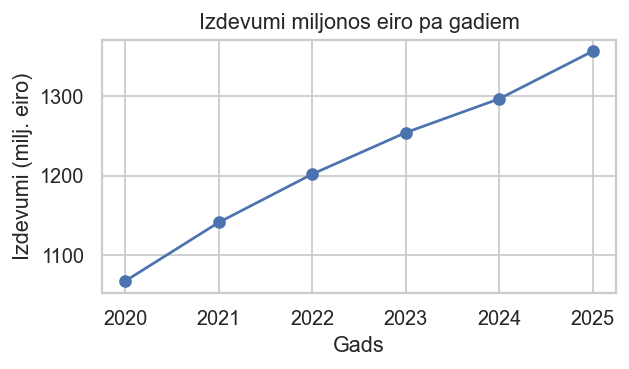

In [ ]:
# 2. Uzzīmējiet līniju grafiku ar matplotlib

# Jūsu kods šeit
import matplotlib.pyplot as plt # zīmējam grafiku ar matplotlib
plt.figure(figsize=(5, 3)) # iestatām grafika izmēru
# tagad izdomājam kas ir x un kas ir y
# x ir gads, y ir izdevumi_milj_eur
plt.plot(izdevumi_pa_gadiem["gads"], izdevumi_pa_gadiem["izdevumi_milj_eur"], marker="o") # zīmējam līniju grafiku ar punktiem
# jāatceras ka matplotlib vizualizācijas ir aktuālas vienas šūnas ietvaros, 
# tāpēc ja mēs izveidosim jaunu grafiku, tad iepriekšējais tiks pārrakstīts, 
# tāpēc šeit mēs varam redzēt tikai vienu grafiku, un tas ir šis līniju grafiks.
#  Ja mēs vēlāk izveidosim citu grafiku, tad šis līniju grafiks vairs nebūs redzams, jo tas tiks pārrakstīts ar jauno grafiku. Tas ir svarīgi atcerēties, jo dažreiz var šķist, ka grafiks nav izveidots, 
# bet patiesībā tas ir izveidots, bet pēc tam pārrakstīts ar citu grafiku.
# uzstādam grafika nosaukumu un asu nosaukumus
plt.title("Izdevumi miljonos eiro pa gadiem")
plt.xlabel("Gads")
plt.ylabel("Izdevumi (milj. eiro)")
# varam arī saglabāt šo grafiku kā attēlu, ja vēlamies to izmantot ārpus Python vidē
# pieliekam nedaudz tapsējumu (padding) lai nebūtu pārāk tuvu malām
plt.tight_layout()
plt.savefig("izdevumi_pa_gadiem.png", dpi=300) # saglabāt ar attiēla kvalitāti 300 dpi, kas ir laba kvalitāte drukāšanai
# parādam grafiku, var arī nerādit, ja tikai glabājam, bet šeit mēs gribam parādīt, tāpēc izmantojam plt.show()
plt.show()

### Uzdevums 4.2. Stabiņu grafiks pa kategorijām

Izveidojiet grafiku, kas salīdzina **kopējos izdevumus pa kategorijām**.

**Padoms:** pirms zīmēšanas sakārtojiet rezultātu dilstošā secībā.


In [ ]:
# TODO:
# 1. Grupējiet datus pēc kategorijas
# 2. Saskaitiet izdevumus
# 3. Sakārtojiet rezultātu
# 4. Uzzīmējiet bar chart

# Jūsu kods šeit


### Uzdevums 4.3. Vairākas līnijas vienā grafikā

Izveidojiet grafiku, kur katra līnija rāda viena reģiona kopējos izdevumus pa gadiem.


In [ ]:
# TODO:
# Izmantojiet pivot_table vai groupby + ciklu

# Jūsu kods šeit


## 5. Seaborn statistiskās vizualizācijas

Seaborn ir īpaši ērts statistisku sadalījumu un salīdzinājumu attēlošanai.


### Uzdevums 5.1. Histogramma

Izveidojiet histogrammu kolonnai `iedzivotaju_apmierinatiba`.

**Prasības:**
- izmantojiet `sns.histplot`,
- norādiet binu skaitu,
- pievienojiet nosaukumu.


In [ ]:
# TODO:
# Jūsu histogrammas kods šeit


### Uzdevums 5.2. Boxplot pa kategorijām

Izveidojiet boxplot, kas salīdzina iedzīvotāju apmierinātību dažādās kategorijās.


In [ ]:
# TODO:
# Jūsu boxplot kods šeit


### Uzdevums 5.3. Scatter plot

Izveidojiet izkliedes grafiku, kur:
- x ass = `izdevumi_milj_eur`
- y ass = `iedzivotaju_apmierinatiba`
- krāsa = `kategorija`


In [ ]:
# TODO:
# Jūsu scatterplot kods šeit


### Uzdevums 5.4. Korelāciju heatmap

Izveidojiet korelāciju matricu tikai skaitliskajām kolonnām un attēlojiet to ar `sns.heatmap`.


In [ ]:
# TODO:
# 1. Atlasiet skaitliskās kolonnas
# 2. Aprēķiniet korelāciju matricu
# 3. Uzzīmējiet heatmap

# Jūsu kods šeit


## 6. Interaktīvās vizualizācijas ar Plotly

Šeit uzdevums ir sajust atšķirību starp statiskiem un interaktīviem grafikiem.


### Uzdevums 6.1. Interaktīvs līniju grafiks

Ar Plotly izveidojiet interaktīvu grafiku kopējiem izdevumiem pa gadiem.


In [ ]:
# TODO:
# Ieteikums: izmantojiet px.line(...)

# Jūsu kods šeit


### Uzdevums 6.2. Interaktīvs stabiņu grafiks

Izveidojiet interaktīvu stabiņu grafiku izdevumiem pa kategorijām.


In [ ]:
# TODO:
# Jūsu Plotly bar chart kods šeit


### Uzdevums 6.3. Interaktīvs scatter plot

Izveidojiet Plotly scatter plot ar:
- krāsu pēc kategorijas,
- punkta izmēru pēc projektu skaita,
- hover informāciju par gadu un reģionu.


In [ ]:
# TODO:
# Jūsu Plotly scatter kods šeit


## 7. Prezentācijām piemēroti grafiki

Aplūkojiet savus iepriekš veidotos grafikus un uzlabojiet vismaz vienu no tiem tā, lai tas būtu piemērots prezentācijai.

### Pārbaudiet:
- vai virsraksts ir skaidrs;
- vai etiķetes ir salasāmas;
- vai nav pārāk daudz vizuāla trokšņa;
- vai ir saprotams galvenais vēstījums.


In [ ]:
# TODO:
# Izvēlieties vienu iepriekšējo grafiku un uzlabojiet to prezentācijai

# Jūsu kods šeit


## 8. Mini projekts

Izveidojiet 3 grafikus:
1. **Matplotlib** — tendence laikā;
2. **Seaborn** — sadalījums vai salīdzinājums;
3. **Plotly** — interaktīva izpēte.

Pie katra grafikā zemāk uzrakstiet īsu interpretāciju:
- ko grafiks rāda,
- kāds ir galvenais secinājums.


In [ ]:
# TODO:
# 1. Matplotlib grafiks
# 2. Seaborn grafiks
# 3. Plotly grafiks
# 4. Tekstiska interpretācija Markdown šūnā zem šīs šūnas


## 9. Pašpārbaudes jautājumi

1. Kad labāk izmantot līniju grafiku, nevis stabiņu grafiku?
2. Kādos gadījumos Seaborn ir ērtāks par Matplotlib?
3. Kāda ir Plotly galvenā priekšrocība?
4. Kāpēc korelācija vēl nenozīmē cēloņsakarību?
5. Kādas ir 3 biežākās kļūdas sliktā grafikā?
